In [1]:
# bibliotecas
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras import utils as np_utils

In [3]:
# carregando os dados
(X_treinamento, y_treinamento), (X_teste, y_teste) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


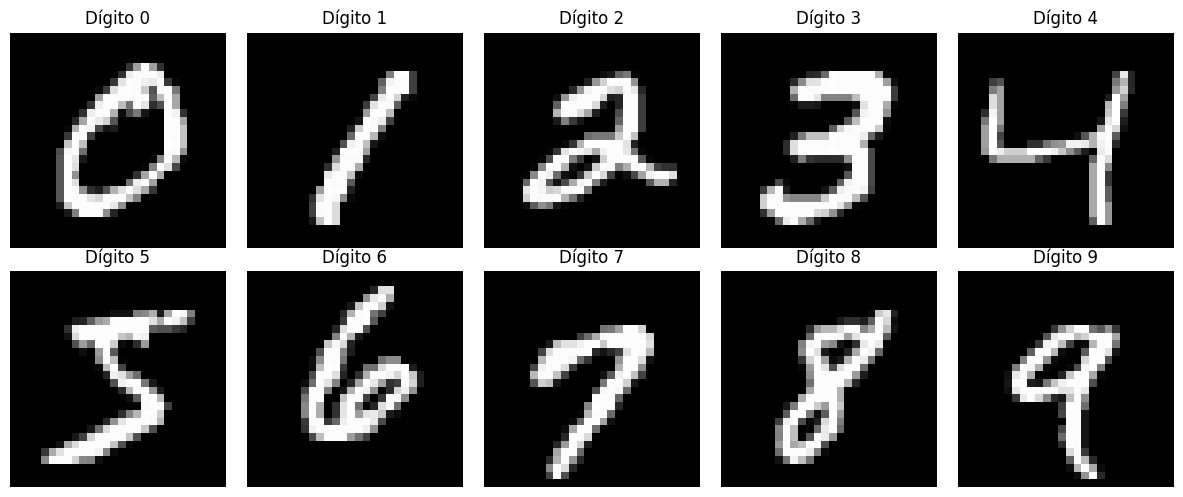

In [4]:
# visualizando exemplos de cada classe
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_treinamento == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.imshow(X_treinamento[idx], cmap='gray')
    ax.set_title(f'Dígito {digit}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# pré-processamento
X_treinamento = X_treinamento.reshape(X_treinamento.shape[0], 28, 28, 1).astype('float32') / 255
X_teste       = X_teste.reshape(X_teste.shape[0], 28, 28, 1).astype('float32') / 255
y_treinamento_cat = np_utils.to_categorical(y_treinamento, 10)
y_teste_cat       = np_utils.to_categorical(y_teste, 10)

In [6]:
# arquitetura com 2 blocos convolucionais
rede_neural = Sequential()
rede_neural.add(InputLayer(shape=(28, 28, 1)))

# bloco 1
rede_neural.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size=(2, 2)))

# bloco 2
rede_neural.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size=(2, 2)))

rede_neural.add(Flatten())
rede_neural.add(Dense(units=256, activation='relu'))
rede_neural.add(Dropout(0.3))
rede_neural.add(Dense(units=10, activation='softmax'))

In [7]:
rede_neural.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,842 (3.15 MB)

 Trainable params: 824,650 (3.15 MB)

 Non-trainable params: 192 (768.00 B)

In [8]:
# compilação
rede_neural.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
# treinamento
historico = rede_neural.fit(X_treinamento, y_treinamento_cat, batch_size=128,
                            epochs=10, validation_data=(X_teste, y_teste_cat))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 237ms/step - accuracy: 0.8862 - loss: 0.4680 - val_accuracy: 0.9659 - val_loss: 0.1228
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 237ms/step - accuracy: 0.9821 - loss: 0.0570 - val_accuracy: 0.9863 - val_loss: 0.0406
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 239ms/step - accuracy: 0.9872 - loss: 0.0386 - val_accuracy: 0.9883 - val_loss: 0.0407
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 237ms/step - accuracy: 0.9907 - loss: 0.0290 - val_accuracy: 0.9906 - val_loss: 0.0360
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 112s 238ms/step - accuracy: 0.9922 - loss: 0.0230 - val_accuracy: 0.9872 - val_loss: 0.0503
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 235ms/step - accuracy: 0.9923 - loss: 0.0238 - val_accuracy: 0.9917 - val_loss: 0.0320
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - accuracy: 0.9934 - loss: 0.0197 - val_accuracy: 0.9934 - val_loss: 0.0289
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 235ms/step - accuracy: 0.9955 -

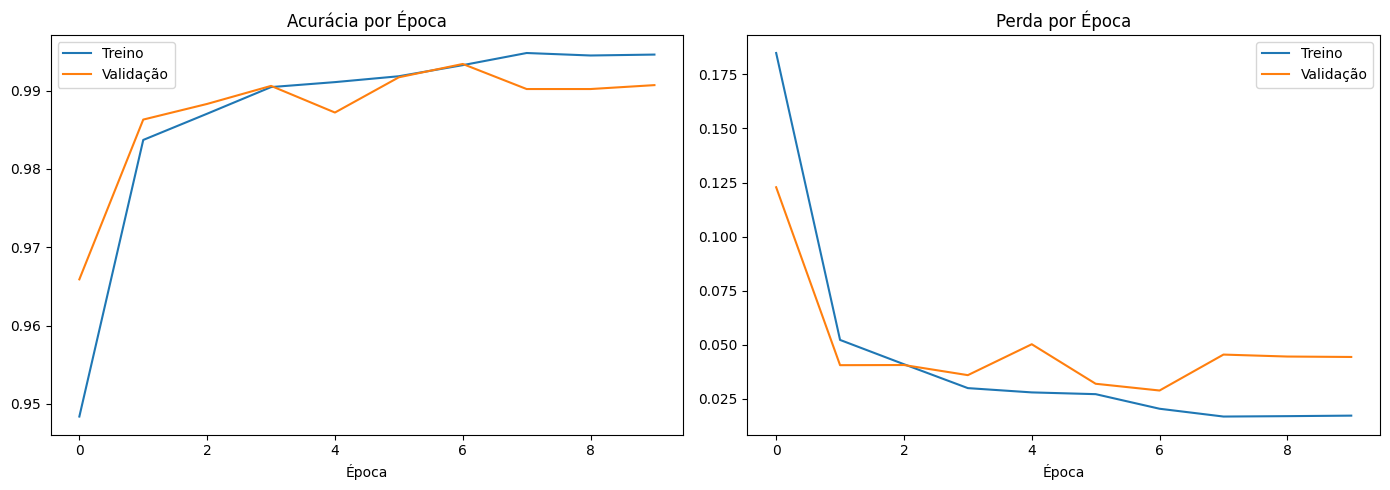

In [10]:
# aqui eu monto dois gráficos lado a lado pra ver a acurácia e a perda de uma vez
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# no primeiro, eu comparo o treino com a validação
axes[0].plot(historico.history['accuracy'], label='Treino')
axes[0].plot(historico.history['val_accuracy'], label='Validação')
axes[0].set_title('Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].legend()

# no segundo, eu vejo a perda (loss) baixando
axes[1].plot(historico.history['loss'], label='Treino')
axes[1].plot(historico.history['val_loss'], label='Validação')
axes[1].set_title('Perda por Época')
axes[1].set_xlabel('Época')
axes[1].legend()

In [12]:
resultado = rede_neural.evaluate(X_teste, y_teste_cat)
print(f'Acurácia: {resultado[1]:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9877 - loss: 0.0570
Acurácia: 0.9907
